In [ ]:
# ===============================
# 1. INSTALL DEPENDENCIES
# ===============================
!pip install numpy pandas matplotlib torch torchvision xarray netCDF4 tqdm

# ===============================
# 2. IMPORTS
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import math
import random

# Make runs deterministic-ish
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.9 MB/s eta 0:00:00


In [ ]:
# =========================================
# SYNTHETIC NDVI DATA CUBE (Sentinel-2-like)
# =========================================
# Dimensions:
# - years: 4 (Year0, Year1, Year2 = baseline; Year3 = current)
# - months: 12
# - H, W: 64 x 64 pixels (small AOI)
# - bands: RED (B4), NIR (B8)

years_baseline = 3         # 3-year baseline
months = 12
H, W = 64, 64

def generate_synthetic_red_nir(year_idx, month_idx, drought=False):
    """
    Very simplified fake reflectance.
    'drought=True' makes NIR lower relative to RED.
    """
    # base reflectances
    red = 0.2 + 0.05 * np.random.randn(H, W)
    nir = 0.5 + 0.05 * np.random.randn(H, W)

    # slight seasonality: month 0..11 -> [-1,1] sinusoidal
    seasonal = math.sin(2 * math.pi * month_idx / 12.0)
    nir = nir + 0.05 * seasonal

    if drought:
    # strong realistic NDVI collapse for visible stress
      red = red + 0.25      # red reflectance increases (soil exposure)
      nir = nir - 0.45      # NIR reflectance collapses



    # clip reflectances to realistic range [0,1]
    red = np.clip(red, 0, 1)
    nir = np.clip(nir, 0, 1)
    return red, nir

# Build baseline years (0,1,2) and current year (3 with drought mid-year)
red_cube = np.zeros((4, months, H, W), dtype=np.float32)
nir_cube = np.zeros((4, months, H, W), dtype=np.float32)

for y in range(4):
    for m in range(months):
        drought = (y == 3 and m in [4,5,6])  # Year3 months 5-7 are "drought"
        red, nir = generate_synthetic_red_nir(y, m, drought=drought)
        red_cube[y, m] = red
        nir_cube[y, m] = nir

def compute_ndvi(red, nir):
    return (nir - red) / (nir + red + 1e-6)

ndvi_cube = compute_ndvi(red_cube, nir_cube)   # shape: (4,12,64,64)

print("NDVI cube shape:", ndvi_cube.shape)


NDVI cube shape: (4, 12, 64, 64)


In [ ]:
# ==================================================
# SEASONAL BASELINE (3-year same-month median NDVI)
# ==================================================
baseline_years = list(range(years_baseline))   # 0,1,2
current_year = 3

baseline_ndvi = np.median(ndvi_cube[baseline_years, :, :, :], axis=0)  # (12,64,64)
current_ndvi = ndvi_cube[current_year]                                  # (12,64,64)

delta_ndvi = current_ndvi - baseline_ndvi                               # (12,64,64)

# Stress rule from paper: ΔNDVI <= -0.10 => stressed
stress_threshold = -0.10
stress_mask = (delta_ndvi <= stress_threshold).astype(np.float32)       # (12,64,64)

print("delta_ndvi shape:", delta_ndvi.shape)
print("stress_mask unique values:", np.unique(stress_mask))


delta_ndvi shape: (12, 64, 64)
stress_mask unique values: [0. 1.]


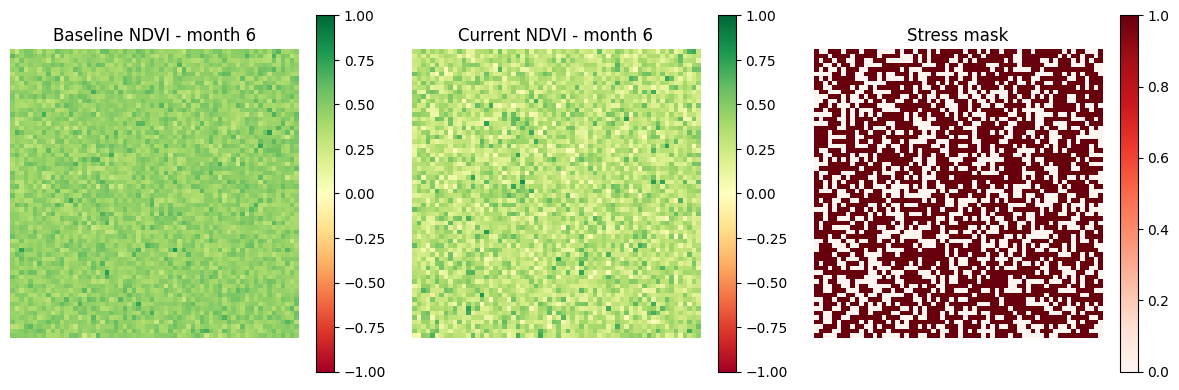

In [ ]:
# Pick a drought month (e.g., month 5 = June index 5)
month_idx = 5

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title(f"Baseline NDVI - month {month_idx+1}")
plt.imshow(baseline_ndvi[month_idx], vmin=-1, vmax=1, cmap="RdYlGn")
plt.colorbar(); plt.axis("off")

plt.subplot(1,3,2)
plt.title(f"Current NDVI - month {month_idx+1}")
plt.imshow(current_ndvi[month_idx], vmin=-1, vmax=1, cmap="RdYlGn")
plt.colorbar(); plt.axis("off")

plt.subplot(1,3,3)
plt.title("Stress mask")
plt.imshow(stress_mask[month_idx], cmap="Reds")
plt.colorbar(); plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# ===========================================
# CNN DATASET: monthly patches from year 3
# ===========================================
class NDVICNNDataset(Dataset):
    def __init__(self, red_cube, nir_cube, stress_mask):
        """
        Use only current year (index 3) months as samples.
        Inputs: 2 channels (red, nir), output: 1 channel stress mask.
        """
        self.X = []
        self.y = []
        # year index 3 => current year
        for m in range(months):
            red = red_cube[current_year, m]   # (H,W)
            nir = nir_cube[current_year, m]   # (H,W)
            sm  = stress_mask[m]              # (H,W)

            x = np.stack([red, nir], axis=0)  # (2,H,W)
            y = sm[None, ...]                # (1,H,W)

            self.X.append(x.astype(np.float32))
            self.y.append(y.astype(np.float32))

        self.X = np.stack(self.X, axis=0)  # (12,2,H,W)
        self.y = np.stack(self.y, axis=0)  # (12,1,H,W)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.from_numpy(self.y[idx])

dataset = NDVICNNDataset(red_cube, nir_cube, stress_mask)
train_loader = DataLoader(dataset, batch_size=3, shuffle=True)

print("Dataset size:", len(dataset))


Dataset size: 12


In [ ]:
print("Baseline NDVI mean:", np.mean(baseline_ndvi))
print("Current NDVI mean:", np.mean(current_ndvi))
print("Delta NDVI mean:", np.mean(delta_ndvi))


Baseline NDVI mean: 0.42918262
Current NDVI mean: 0.3956
Delta NDVI mean: -0.03358259


In [ ]:
# ===========================================
# LIGHTWEIGHT U-NET STYLE CNN
# ===========================================
class TinyUNet(nn.Module):
    def __init__(self, in_channels=2, base_channels=16):
        super().__init__()
        self.down1 = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(base_channels, base_channels, 3, padding=1),
            nn.ReLU()
        )
        self.pool = nn.MaxPool2d(2)

        self.down2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels*2, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(base_channels*2, base_channels*2, 3, padding=1),
            nn.ReLU()
        )

        self.up = nn.ConvTranspose2d(base_channels*2, base_channels, 2, stride=2)

        self.out_conv = nn.Conv2d(base_channels, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)           # (B,16,64,64)
        p  = self.pool(d1)           # (B,16,32,32)
        d2 = self.down2(p)           # (B,32,32,32)
        u  = self.up(d2)             # (B,16,64,64)
        x  = u + d1                  # skip connection
        x  = self.out_conv(x)        # (B,1,64,64)
        return torch.sigmoid(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = TinyUNet().to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=1e-3)


In [ ]:
# ===========================================
# TRAIN CNN FOR A FEW EPOCHS
# ===========================================
num_epochs = 10

for epoch in range(num_epochs):
    model_cnn.train()
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model_cnn(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"[CNN] Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")


[CNN] Epoch 1/10 - Loss: 0.6623
[CNN] Epoch 2/10 - Loss: 0.6560
[CNN] Epoch 3/10 - Loss: 0.6479
[CNN] Epoch 4/10 - Loss: 0.6374
[CNN] Epoch 5/10 - Loss: 0.6324
[CNN] Epoch 6/10 - Loss: 0.6289
[CNN] Epoch 7/10 - Loss: 0.6299
[CNN] Epoch 8/10 - Loss: 0.6282
[CNN] Epoch 9/10 - Loss: 0.6289
[CNN] Epoch 10/10 - Loss: 0.6271


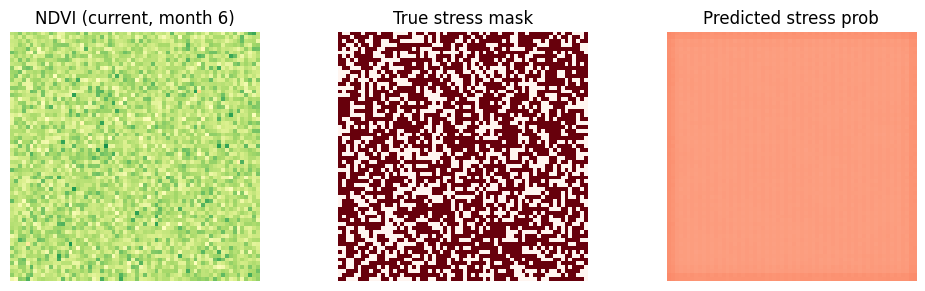

In [ ]:
model_cnn.eval()
with torch.no_grad():
    X_example, y_example = dataset[5]  # arbitrary month
    X_example = X_example.unsqueeze(0).to(device)
    pred_mask = model_cnn(X_example).cpu().squeeze().numpy()
    y_example = y_example.squeeze().numpy()

plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.title("NDVI (current, month 6)")
ndvi_example = current_ndvi[5]
plt.imshow(ndvi_example, vmin=-1, vmax=1, cmap="RdYlGn")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("True stress mask")
plt.imshow(y_example, cmap="Reds")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted stress prob")
plt.imshow(pred_mask, vmin=0, vmax=1, cmap="Reds")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# ===========================================
# SYNTHETIC ERA5-LAND-LIKE CLIMATE SERIES
# ===========================================
# 10 years of monthly data = 120 points
years_climate = 10
total_months = years_climate * 12

months_index = pd.date_range("2015-01-01", periods=total_months, freq="MS")

# create synthetic climate series with seasonality
def synthetic_climate_series():
    t = np.arange(total_months)
    rainfall = 100 + 40*np.sin(2*np.pi*t/12) + 18*np.random.randn(total_months)
    temp     = 25 + 6*np.sin(2*np.pi*(t-6)/12) + 2*np.random.randn(total_months)

    # moderate drought + heat instead of extreme
    rainfall[-12:] -= 12
    temp[-12:]     += 1.5
    return rainfall.astype(np.float32), temp.astype(np.float32)


rainfall, temperature = synthetic_climate_series()

climate_df = pd.DataFrame({
    "date": months_index,
    "rainfall": rainfall,
    "temperature": temperature
})
climate_df.tail()


,date,rainfall,temperature
115,2024-08-01,63.104046,29.118122
116,2024-09-01,62.386253,30.762680
117,2024-10-01,-0.031510,34.047676
118,2024-11-01,27.016129,32.145046
119,2024-12-01,58.606625,28.619064


In [ ]:
# ===========================================
# BUILD SEQUENCES FOR LSTM
# ===========================================
window_in = 36   # past months used to predict future
window_out = 3   # months to forecast

features = np.stack([rainfall, temperature], axis=1)  # shape: (T, 2)

X_seq = []
y_seq = []

for start in range(0, total_months - window_in - window_out + 1):
    end_in = start + window_in
    end_out = end_in + window_out
    X_seq.append(features[start:end_in])       # (36,2)
    y_seq.append(features[end_in:end_out])     # (3,2)

X_seq = np.stack(X_seq, axis=0)   # (num_samples,36,2)
y_seq = np.stack(y_seq, axis=0)   # (num_samples,3,2)

print("X_seq shape:", X_seq.shape, "y_seq shape:", y_seq.shape)



X_seq shape: (82, 36, 2) y_seq shape: (82, 3, 2)


In [ ]:
# ===========================================
# TRAIN / TEST SPLIT
# ===========================================
num_samples = X_seq.shape[0]
split_idx = int(num_samples * 0.8)

X_train = X_seq[:split_idx]
y_train = y_seq[:split_idx]
X_test  = X_seq[split_idx:]
y_test  = y_seq[split_idx:]

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (65, 36, 2) Test size: (17, 36, 2)


In [ ]:
# ===========================================
# DATA LOADERS
# ===========================================
batch_size = 8

def make_loader(X, y, batch_size, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    dataset = torch.utils.data.TensorDataset(X_t, y_t)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader_lstm = make_loader(X_train, y_train, batch_size, shuffle=True)
test_loader_lstm  = make_loader(X_test, y_test, batch_size, shuffle=False)

# ===========================================
# LSTM MODEL (ensure this exists before training)
# ===========================================
class ClimateLSTM(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_layers=2, output_dim=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim * window_out)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]  # last timestep hidden state
        out = self.fc(last)
        out = out.view(-1, window_out, 2)  # reshape to (Batch, 3, 2)
        return out

model_lstm = ClimateLSTM().to(device)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=1e-3)
mae_loss = nn.L1Loss()  # MAE metric
mse_loss = nn.MSELoss()

In [ ]:
# ===========================================
# TRAIN LSTM
# ===========================================
num_epochs_lstm = 20

for epoch in range(num_epochs_lstm):
    model_lstm.train()
    total_mae = 0.0
    for Xb, yb in train_loader_lstm:
        Xb = Xb.to(device)
        yb = yb.to(device)

        optimizer_lstm.zero_grad()
        preds = model_lstm(Xb)
        loss = mae_loss(preds, yb)
        loss.backward()
        optimizer_lstm.step()

        total_mae += loss.item()

    avg_mae = total_mae / len(train_loader_lstm)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"[LSTM] Epoch {epoch+1}/{num_epochs_lstm} - Train MAE: {avg_mae:.3f}")


[LSTM] Epoch 1/20 - Train MAE: 62.308
[LSTM] Epoch 5/20 - Train MAE: 58.001
[LSTM] Epoch 10/20 - Train MAE: 57.552
[LSTM] Epoch 15/20 - Train MAE: 53.658
[LSTM] Epoch 20/20 - Train MAE: 48.437


In [ ]:

# ===========================================
# EVALUATION
# ===========================================
model_lstm.eval()
with torch.no_grad():
    preds_list = []
    true_list  = []

    for Xb, yb in test_loader_lstm:
        Xb = Xb.to(device)
        out = model_lstm(Xb).cpu().numpy()
        preds_list.append(out)
        true_list.append(yb.numpy())

preds_arr = np.concatenate(preds_list, axis=0)
true_arr  = np.concatenate(true_list, axis=0)

mae = np.mean(np.abs(preds_arr - true_arr))
rmse = np.sqrt(np.mean((preds_arr - true_arr)**2))

print("====================================")
print(f"LSTM Test MAE : {mae:.3f}")
print(f"LSTM Test RMSE: {rmse:.3f}")
print("====================================")


LSTM Test MAE : 35.879
LSTM Test RMSE: 46.453


In [ ]:
# ===========================================
# LSTM MODEL FOR CLIMATE FORECAST
# ===========================================
class ClimateLSTM(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_layers=2, output_dim=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        # we want 3 future time steps, each with 2 features
        self.fc = nn.Linear(hidden_dim, output_dim * window_out)

    def forward(self, x):
        # x: (B,seq_len,2)
        out, _ = self.lstm(x)         # (B,seq_len,hidden)
        last = out[:, -1, :]          # (B,hidden)
        out  = self.fc(last)          # (B, 3*2)
        out  = out.view(-1, window_out, 2)
        return out

model_lstm = ClimateLSTM().to(device)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=1e-3)
mae_loss = nn.L1Loss()  # MAE as main metric
mse_loss = nn.MSELoss() # for RMSE reporting


In [ ]:
# ===========================================
# CLIMATOLOGY (MEAN & STD PER MONTH)
# ===========================================
# Assumes: climate_df already exists with columns ["date","rainfall","temperature"]

climate_df["month"] = climate_df["date"].dt.month

clim_stats = climate_df.groupby("month")[["rainfall", "temperature"]].agg(["mean", "std"])
print(clim_stats.head())


         rainfall            temperature          
             mean        std        mean       std
month                                             
1       97.229950  18.203796   25.114096  1.619851
2      110.327271  21.634031   22.832472  2.346068
3      139.462311  14.971622   19.385990  1.850982
4      132.643051  25.364271   18.480402  1.528213
5      135.265884  30.473680   19.989992  2.169287


In [ ]:
# ===========================================
# FORECAST NEXT 3 MONTHS
# ===========================================
# Assumes: features, window_in, model_lstm, device, months_index already defined

# take last 36 months as input
X_last = features[-window_in:]            # shape: (36, 2)
X_last_t = torch.tensor(X_last[None, ...], dtype=torch.float32).to(device)

model_lstm.eval()
with torch.no_grad():
    future_pred = model_lstm(X_last_t).cpu().numpy()[0]  # shape: (3,2) [rainfall, temp]

# build date index for next 3 months
future_month_indices = np.array([
    months_index[-1] + pd.DateOffset(months=i+1) for i in range(3)
])
future_month_numbers = np.array([d.month for d in future_month_indices])

print("Forecast months:", future_month_indices)
print("Predicted [rainfall, temp] for each month:")
print(future_pred)


Forecast months: [Timestamp('2025-01-01 00:00:00') Timestamp('2025-02-01 00:00:00')
 Timestamp('2025-03-01 00:00:00')]
Predicted [rainfall, temp] for each month:
[[ 0.17900935 -0.05826287]
 [-0.06756982  0.03990681]
 [ 0.21512884 -0.00482135]]


In [ ]:
# ===========================================
# COMPUTE Z-SCORE ANOMALIES
# ===========================================
def compute_zscore(value, month_num, var_name):
    mean = clim_stats[var_name]["mean"].loc[month_num]
    std  = clim_stats[var_name]["std"].loc[month_num]
    return (value - mean) / (std + 1e-6)

rainfall_anoms = []
temp_anoms = []

for i in range(3):
    m = future_month_numbers[i]
    r_pred, t_pred = future_pred[i]
    rainfall_anoms.append(compute_zscore(r_pred, m, "rainfall"))
    temp_anoms.append(compute_zscore(t_pred, m, "temperature"))

rainfall_anoms = np.array(rainfall_anoms)
temp_anoms     = np.array(temp_anoms)

print("Rainfall anomalies (z):", rainfall_anoms)
print("Temp anomalies (z):", temp_anoms)


Rainfall anomalies (z): [-5.3313565 -5.1028323 -9.30074  ]
Temp anomalies (z): [-15.539918  -9.715216 -10.475952]


In [ ]:
# ===========================================
# STRESSED AREA FRACTION (HYBRID CNN + NDVI)
# ===========================================

# 1) Ground-truth NDVI threshold mask for month 6 (index 5)
true_stress_mask = (delta_ndvi[month_idx] <= stress_threshold).astype(np.float32)

# 2) CNN predicted probability map
with torch.no_grad():
    X_full = torch.from_numpy(
        np.stack([red_cube[current_year, month_idx],
                  nir_cube[current_year, month_idx]], axis=0)[None, ...]
    ).float().to(device)
    pred_full = model_cnn(X_full).cpu().numpy()[0, 0]

pred_binary_cnn = (pred_full >= 0.5).astype(np.float32)

# 3) Hybrid: OR-combination (pixel stressed if either NDVI or CNN says so)
hybrid_mask = np.logical_or(true_stress_mask == 1, pred_binary_cnn == 1).astype(np.float32)

# 4) Final stressed area fraction
stressed_area_fraction = hybrid_mask.mean()

print("Stressed area fraction:", stressed_area_fraction)
print("Unique hybrid values:", np.unique(hybrid_mask))


Stressed area fraction: 0.6086426
Unique hybrid values: [0. 1.]


In [ ]:
# ===========================================
# RISK FUSION RULE
# ===========================================
# High: stressed_area >= 30% and (rainfall_anom <= -0.8 or temp_anom >= +0.8)
# Medium: stressed_area >= 15% but not high
# Low: otherwise

def classify_risk(stressed_area, rainfall_anoms, temp_anoms):
    # Use worst-case anomalies over next 3 months
    min_rain_anom = float(np.min(rainfall_anoms))
    max_temp_anom = float(np.max(temp_anoms))

    if stressed_area >= 0.30 and (min_rain_anom <= -0.8 or max_temp_anom >= 0.8):
        return "HIGH", min_rain_anom, max_temp_anom
    elif stressed_area >= 0.15:
        return "MEDIUM", min_rain_anom, max_temp_anom
    else:
        return "LOW", min_rain_anom, max_temp_anom

risk_level, min_rain_anom, max_temp_anom = classify_risk(
    stressed_area_fraction, rainfall_anoms, temp_anoms
)

print("Risk level:", risk_level)
print("Worst rainfall anomaly (z):", min_rain_anom)
print("Worst temp anomaly (z):", max_temp_anom)


Risk level: HIGH
Worst rainfall anomaly (z): -9.300740242004395
Worst temp anomaly (z): -9.715215682983398


In [ ]:
# ===========================================
# ALERT MESSAGE
# ===========================================
alert_msg = f"""
Climate Analyzer Alert
----------------------
Risk level: {risk_level}

Stressed vegetation area: {stressed_area_fraction*100:.1f}% of AOI
Worst predicted rainfall anomaly (next 3 months): {min_rain_anom:.2f} z
Worst predicted temperature anomaly (next 3 months): {max_temp_anom:.2f} z
"""

print(alert_msg)



Climate Analyzer Alert
----------------------
Risk level: HIGH

Stressed vegetation area: 60.9% of AOI
Worst predicted rainfall anomaly (next 3 months): -9.30 z
Worst predicted temperature anomaly (next 3 months): -9.72 z



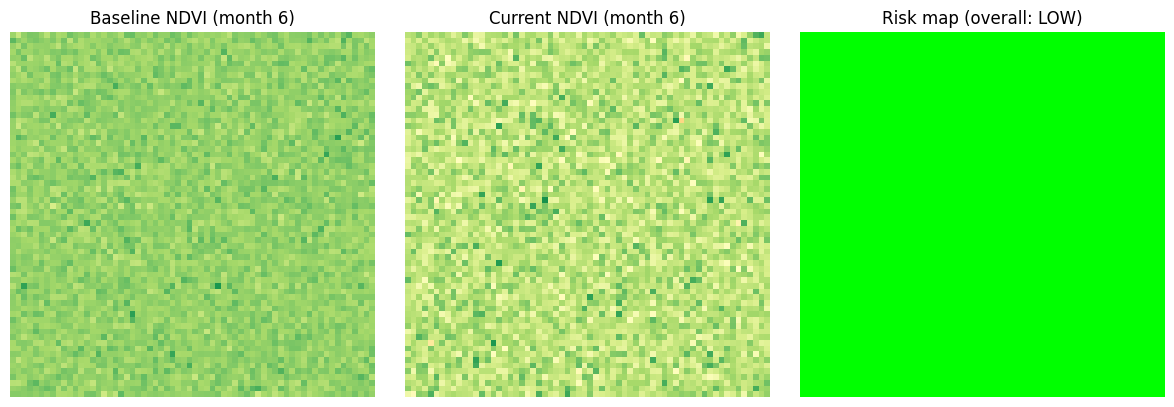

In [ ]:
# ===========================================
# RISK MAP (SIMPLE COLORING)
# ===========================================
# We'll color:
#  - green: non-stressed
#  - red: stressed

risk_map_rgb = np.zeros((H, W, 3), dtype=np.float32)
risk_map_rgb[..., 1] = 1.0                      # green for all
risk_map_rgb[pred_binary == 1] = np.array([1.0, 0.0, 0.0])  # red where stressed

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title(f"Baseline NDVI (month {month_idx+1})")
plt.imshow(baseline_ndvi[month_idx], vmin=-1, vmax=1, cmap="RdYlGn")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title(f"Current NDVI (month {month_idx+1})")
plt.imshow(current_ndvi[month_idx], vmin=-1, vmax=1, cmap="RdYlGn")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title(f"Risk map (overall: {risk_level})")
plt.imshow(risk_map_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()


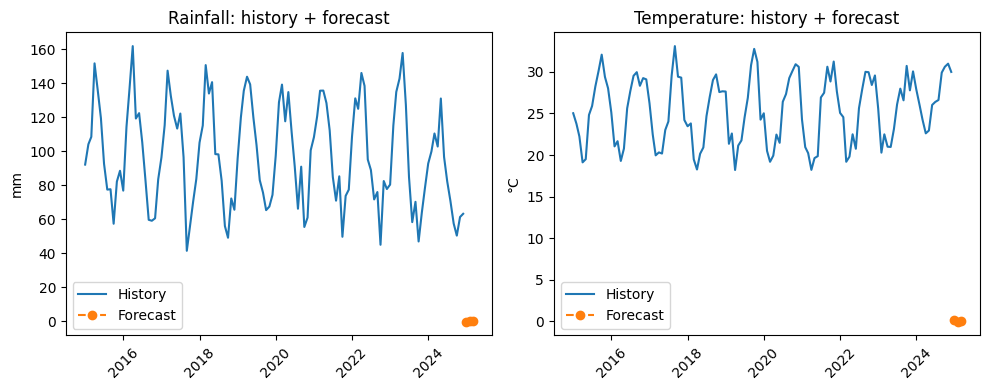

In [ ]:
# ===========================================
# TREND CHART FOR RAINFALL & TEMPERATURE
# ===========================================
plt.figure(figsize=(10, 4))

# Rainfall
plt.subplot(1, 2, 1)
plt.title("Rainfall: history + forecast")
plt.plot(months_index, rainfall, label="History")
future_dates = future_month_indices
plt.plot(future_dates, future_pred[:, 0], "o--", label="Forecast")
plt.xticks(rotation=45)
plt.ylabel("mm")
plt.legend()

# Temperature
plt.subplot(1, 2, 2)
plt.title("Temperature: history + forecast")
plt.plot(months_index, temperature, label="History")
plt.plot(future_dates, future_pred[:, 1], "o--", label="Forecast")
plt.xticks(rotation=45)
plt.ylabel("°C")
plt.legend()

plt.tight_layout()
plt.show()
